<a href="https://colab.research.google.com/github/alzimnara/modul_praktikum/blob/main/notebooks/Notebook_Bab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install contextily osmnx rioxarray exactextract damagescanner
from damagescanner.core import DamageScanner

import contextily as ctx
import osmnx as ox

import pyproj
from exactextract import exact_extract
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import geopandas as gpd

from typing import Union
import shapely
from shapely.geometry import mapping,Polygon

import xarray as xr
import rasterio
import rioxarray

import matplotlib.pyplot as plt
plt.rcParams["savefig.dpi"] = 600
import seaborn as sns

import time
from tqdm import tqdm

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

# Menyiapkan Batas Daerah Studi

In [3]:
class Daerah:
    """
    Kelas untuk merepresentasikan dan memvisualisasikan batas administrasi daerah.
    Parameters
    ----------
    nama_daerah : str
        Nama daerah yang akan di-geocode. Pastikan tersedia di web OSM.
    Attributes
    ----------
    nama : str
        Nama daerah tanpa sufiks negara.
    gdf : geopandas.GeoDataFrame
        Geometri batas daerah sebagai GeoDataFrame.
    crs : Any
        Coordinate reference dari data asli.
    geom : shapely.geometry
        Geometri batas daerah sebagai objek Shapely.
    gdf_proj : geopandas.GeoDataFrame
        Geometri batas daerah yang diproyeksikan ke EPSG:3857 (Web Mercator)
        untuk keperluan plotting.
    BASEMAPS : dict
        Konstanta kelas yang memetakan nama basemap ke URL tile atau provider-nya.
    """

    BASEMAPS = {
        "osm": ctx.providers.OpenStreetMap.Mapnik,
        "cartodb_positron": ctx.providers.CartoDB.Positron,
        "cartodb_voyager": ctx.providers.CartoDB.Voyager,
        "google_satellite": "https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
        "google_hybrid": "https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}",
    }

    def __init__(self, nama_daerah: str) -> None:
        """
        Geocode nama tempat dan inisialisasi objek daerah.
        Raises
        ------
        ValueError
            Jika nama tempat tidak dapat di-geocode atau mengembalikan hasil kosong.
        """
        self.nama = nama_daerah.split(", ")[0]

        # mengambil data dari osmnx
        try:
            self.gdf = ox.geocode_to_gdf(nama_daerah)
            if self.gdf.empty:
                raise ValueError(f"Data '{nama_daerah}' tidak ditemukan")
        except Exception as e:
            raise ValueError((f"Data '{nama_daerah}' tidak ditemukan.\n"
                              f"Error: {str(e)}"))

        # mengetahui crs dari gdf
        self.crs = self.gdf.crs

        # mengambil objek geometri untuk batas daerah dari gdf
        self.geom = self.gdf.geometry.iloc[0]

        # proyeksi gdf dalam meter untuk plotting
        self.gdf_proj = self.gdf.to_crs(epsg=3857)

    def plot(
        self,
        basemap: str = None,
        padding: float = 1000,
        savefig: bool = False,
        ax: plt.Axes = None
    ) -> None:
        """
        Plot batas daerah dengan peta dasar (basemap) opsional.
        Parameters
        ----------
        basemap : str, optional
            Peta dasar yang akan digunakan. Harus merupakan salah satu kunci dalam
            BASEMAPS. Pilihan: "osm", "cartodb_positron", "cartodb_voyager",
            "google_satellite", "google_hybrid". Jika None, tidak menambahkan peta dasar.
        padding : float, default=1000
            Jarak (dalam meter) yang ditambahkan di sekitar batas daerah saat
            mengatur batas plot.
        savefig : bool, default=False
            Jika True, menyimpan figure dengan nama file dari `self.nama`.
        ax : matplotlib.pyplot.Axes, optional
            Sumbu untuk plotting jika ada. Jika None, akan membuat sumbu baru.
        Returns
        -------
        matplotlib.figure.Figure
            Objek matplotlib figure yang berisi hasil plot.
        """

        if ax is None:
          fig = plt.figure(figsize=(5, 5))
          ax = plt.axes()
        else:
            fig = ax.figure

        # Mendapatkan batas persegi panjang dari gdf_proj
        bounds = self.gdf_proj.geometry.total_bounds

        # Membuat batas plot sesuai bounds supaya memuat gdf_proj
        ax.set_xlim(bounds[0] - padding, bounds[2] + padding)
        ax.set_ylim(bounds[1] - padding, bounds[3] + padding)

        # Menambahkan basemap jika diperlukan
        if basemap:
            source = self.BASEMAPS.get(basemap)
            ctx.add_basemap(ax,
                            source=source,
                            zorder=1)

        self.gdf_proj.plot(ax=ax,
                           facecolor='none',
                           edgecolor='red',
                           linewidth=2,
                           alpha=0.5,
                           zorder=2)

        ax.set_axis_off()
        plt.tight_layout()

        # menyimpan hasil plotting jika diperlukan
        if savefig:
          if basemap:
            plt.savefig(f"{self.nama}_{basemap}")
          else :
            plt.savefig(f"{self.nama}_plain")

        return fig

Waktu eksekusi: 2.453993082046509 detik


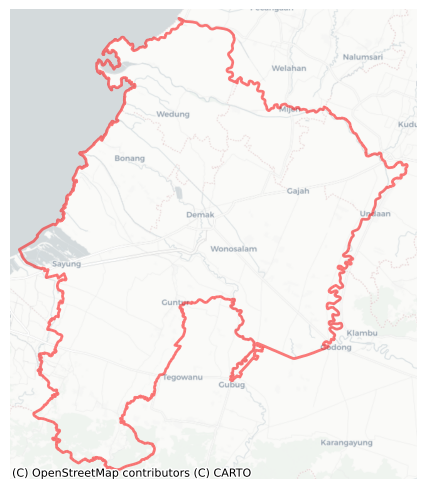

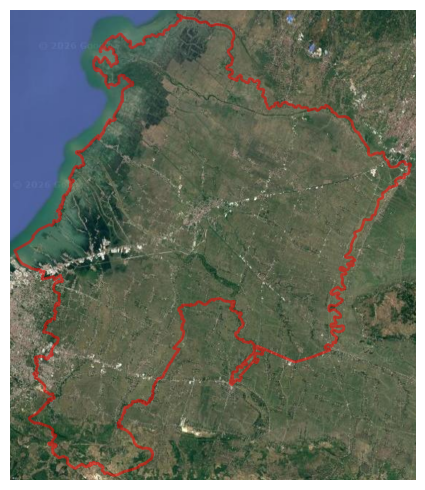

In [4]:
start = time.time()
demak = Daerah("Demak, Jawa Tengah, Jawa, Indonesia")
print(f"Waktu eksekusi: {time.time()-start} detik")
#plotting dengan basemap positron, padding 1000 m, dan tanpa menyimpan gambar
demak.plot(basemap="cartodb_positron").show()
#plotting dengan basemap GS, padding 500 m, dan menyimpan gambar
demak.plot(basemap="google_satellite", padding=500, savefig=True).show()

In [5]:
# basemaps = [None,"osm","cartodb_positron","google_hybrid"]
# for basemap in basemaps:
#   demak.plot(basemap=basemap,savefig=True)

# Menyiapkan Data Hazard

In [6]:
def _crop_hazard(hazard_map: xr.DataArray,
                 region_gdf: gpd.GeoDataFrame) -> xr.DataArray:
    """
    Cropping peta hazard berdasarkan batas wilayah administrasi.

    Parameters
    ----------
    hazard_map : xr.DataArray
        Peta bahaya dalam format xarray dengan accessor 'rio'.
    region_gdf : geopandas.GeoDataFrame
        GeoDataFrame yang berisi geometri batas wilayah untuk memotong hazard_map.

    Returns
    -------
    xr.DataArray
        Peta bahaya yang sudah dipotong (clipped) sesuai batas wilayah.

    """
    #Mengambil batas terluar dari region_gdf untuk pembuatan box
    bounds = region_gdf.geometry.total_bounds
    #Clipping peta hazard dengan box
    clipped_box = hazard_map.rio.clip_box(*bounds)
    #Clipping peta hazard dengan region_gdf
    hazard_clipped = clipped_box.rio.clip(region_gdf.geometry)

    return hazard_clipped

In [7]:
hazard_rp100 = rioxarray.open_rasterio(
    filename = "https://hazards-data.unepgrid.ch/global_pc_h100glob.tif",
    masked = True
    )

print('demak.gdf crs: ', demak.gdf.crs)
print('hazard crs: ', hazard_rp100.rio.crs)

hazard_rp100_clipped = _crop_hazard(hazard_rp100,demak.gdf)

demak.gdf crs:  epsg:4326
hazard crs:  EPSG:4326


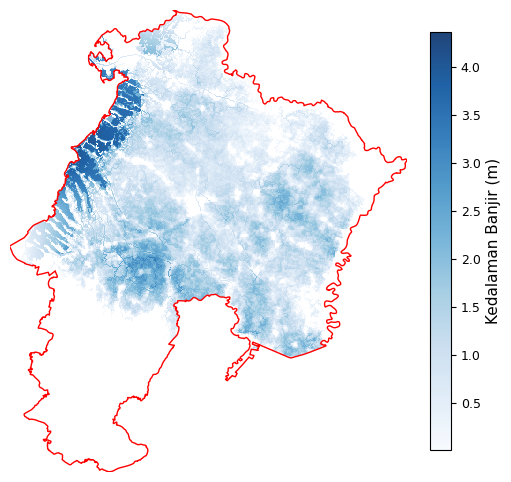

Waktu eksekusi: 5.793511629104614 detik


In [8]:
start = time.time()

f, ax = plt.subplots(figsize=(6, 6))

hazard_rp100_clipped.data = hazard_rp100_clipped.data/100

#Plot raster
im = hazard_rp100_clipped.plot(
    ax=ax,
    cmap="Blues",
    alpha=0.9,
    add_colorbar=False
)

# Custom colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.05)
cbar.set_label("Kedalaman Banjir (m)", fontsize=11, fontweight='medium')
cbar.ax.tick_params(labelsize=9)

# Plot boundary
demak.gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red"
)

ax.set_title('')
ax.set_axis_off()

plt.tight_layout
plt.savefig("demak_rp100.png", bbox_inches="tight")
plt.show()
print(f"Waktu eksekusi: {time.time()-start} detik")

# Menyiapkan Data Exposure

## Download data dengan osmnx

**Download Data Jalan Raya**

In [9]:
class Jalan:
    """
    Kelas untuk merepresentasikan dan membersihkan data jaringan jalan dari OSM.
    """
    focused_types = ["motorway", "trunk", "primary",
                     "secondary", "tertiary", "residential"]
    def __init__(self,
                 region_geom: Union[Polygon, gpd.GeoSeries]
        ) -> None:
        """
        Inisialisasi objek Jalan dengan data dari OSM.
        Parameters
        ----------
        region_geom : shapely.geometry.Polygon atau geopandas.GeoSeries
            Geometri wilayah yang akan diambil data jalannya.
        """
        self._download_road_data(region_geom)
        self.raw_numbers = len(self.gdf_raw)
        self.gdf_cleaned = self._clean_raw_data(region_geom)
        self.cleaned_numbers = len(self.gdf_cleaned)

    def _download_road_data(self,
                 region_geom: Union[Polygon, gpd.GeoSeries]
        ) -> None:
        """
        Mengunduh data jalan dari OSM berdasarkan geometri wilayah.
        Parameters
        ----------
        region_geom : shapely.geometry.Polygon atau geopandas.GeoSeries
            Geometri wilayah untuk batasan download data.
        Returns
        -------
        geopandas.GeoDataFrame
            Data jalan mentah dengan kolom id, highway, dan geometry.
        Raises
        ------
        ValueError
            Jika wilayah tidak memiliki data jalan di OSM.
        """
        tags = {"highway": True}
        self.gdf_raw = ox.features.features_from_polygon(region_geom, tags)

        # Hanya mengambil fitur dengan geometri LineString atau MultiLineString
        self.gdf_raw = (self.gdf_raw[self.gdf_raw.geom_type
                           .isin(["LineString", "MultiLineString"])])

        if "highway" not in self.gdf_raw.columns:
            raise ValueError("Daerah tidak mempunyai data jalan di OSM.")

        # Explode MultiLineString dan reset index
        self.gdf_raw = (
            self.gdf_raw.explode(index_parts=False)
                        .reset_index(drop=False)
        )

        # Memilih kolom yang relevan
        self.gdf_raw = self.gdf_raw[["id", "highway", "geometry"]]

    def _clean_raw_data(self,region_geom) -> gpd.GeoDataFrame:
        """
        Membersihkan dan memfilter data jalan mentah.

        Returns
        -------
        geopandas.GeoDataFrame
            Data jalan yang sudah dibersihkan dengan tipe jalan yang sesuai
            dengan focused_types.
        """
        # Mengganti tipe jalan link menjadi tipe utama
        cleaned = self.gdf_raw.copy()
        cleaned["highway"] = cleaned["highway"].replace({
            "motorway_link": "motorway",
            "trunk_link": "trunk",
            "primary_link": "primary",
            "secondary_link": "secondary",
            "tertiary_link": "tertiary"
        })

        # Mengganti nama kolom
        cleaned = cleaned.rename(columns={"highway": "object_type"})

        # Memfilter berdasarkan focused_types
        cleaned = (
            cleaned[cleaned["object_type"].isin(self.focused_types)]
            .reset_index(drop=True)
        )

        # Melakukan clipping untuk membuang ruas jalan di luar batas daerah
        cleaned = gpd.clip(cleaned,region_geom)

        return cleaned

In [10]:
start = time.time()
infrastruktur = Jalan(demak.geom)
print(f"Banyaknya data sebelum dibersihkan: {infrastruktur.raw_numbers}")
print(f"Banyaknya data setelah dibersihkan: {infrastruktur.cleaned_numbers}")
infrastruktur_gdf = infrastruktur.gdf_cleaned
print(f"Waktu eksekusi: {time.time()-start} detik")
infrastruktur_gdf.head(5)

Banyaknya data sebelum dibersihkan: 29101
Banyaknya data setelah dibersihkan: 22080
Waktu eksekusi: 127.76819133758545 detik


,id,object_type,geometry
20838,1297006145,secondary,"LINESTRING (110.54739 -7.13399, 110.54779 -7.1..."
18159,926648676,residential,"LINESTRING (110.5513 -7.12903, 110.55136 -7.12..."
18653,962553588,residential,"LINESTRING (110.55303 -7.12839, 110.55317 -7.1..."
18186,926669083,residential,"LINESTRING (110.55167 -7.12827, 110.55193 -7.1..."
18594,962472991,residential,"LINESTRING (110.55191 -7.12768, 110.55203 -7.1..."


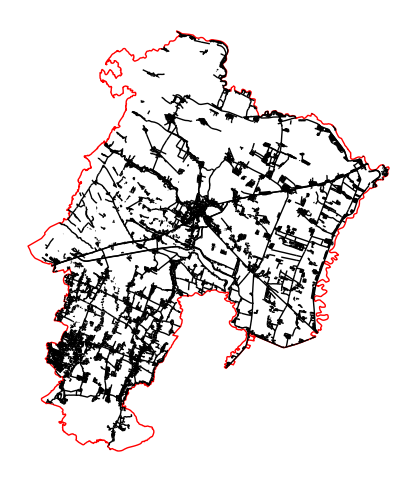

Waktu eksekusi: 2.0034029483795166 detik


In [11]:
start = time.time()
f, ax = plt.subplots(figsize=(6, 6))

# Plot boundary
demak.gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red"
)
infrastruktur_gdf.plot(
    ax=ax,
    linewidth=1,
    edgecolor="black"
)

ax.set_title('')
ax.set_axis_off()

plt.tight_layout
plt.savefig("demak_road.png", bbox_inches="tight")
plt.show()
print(f"Waktu eksekusi: {time.time()-start} detik")

**Download Data Bangunan Publik (Sekolah dan Fasilitas Kesehatan)**

In [12]:
def _remove_containing_polys(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Menghapus polygon yang memuat polygon lain (nested polygons).

    Parameters
    ----------
    gdf : geopandas.GeoDataFrame
        GeoDataFrame yang berisi polygon-polygon yang akan dibersihkan.

    Returns
    -------
    geopandas.GeoDataFrame
        GeoDataFrame yang sudah dibersihkan dari polygon yang memuat polygon lain.
    """
    # Memisahkan polygon dan multipolygon untuk diproses
    polygon_gdf = gdf[gdf.geometry.type.isin(["Polygon", "MultiPolygon"])]

    # Spatial join untuk menemukan polygon yang memuat polygon lain
    contained = gpd.sjoin(
        polygon_gdf,
        polygon_gdf,
        predicate="contains",
    )

    # Mengidentifikasi polygon yang memuat polygon lain (bukan dirinya sendiri)
    subset = contained[contained.index != contained.index_right]
    to_drop = set(subset.index)

    # Menghapus polygon yang memuat polygon lain
    return gdf.drop(index=to_drop).reset_index(drop=True)

class Publik:
    """
    Kelas untuk merepresentasikan dan membersihkan data fasilitas publik dari OSM.
    """

    def __init__(self,
                 region_geom: Union[Polygon, gpd.GeoSeries]
                 ) -> None:
        """
        Inisialisasi objek Publik dengan data dari OSM.

        Parameters
        ----------
        region_geom : shapely.geometry.Polygon atau geopandas.GeoSeries
            Geometri wilayah yang akan diambil data fasilitas publiknya.
        """
        self._download_publik_data(region_geom)
        self.raw_numbers = len(self.gdf_raw)
        self.gdf_cleaned = self._clean_raw_data()
        self.cleaned_numbers = len(self.gdf_cleaned)

    def _download_publik_data(self,
                              region_geom: Union[Polygon, gpd.GeoSeries]
                              ) -> None:
        """
        Mengunduh data fasilitas publik dari OSM berdasarkan geometri wilayah.

        Parameters
        ----------
        region_geom : shapely.geometry.Polygon atau geopandas.GeoSeries
            Geometri wilayah untuk batasan download data.

        Raises
        ------
        ValueError
            Jika wilayah tidak memiliki data fasilitas publik di OSM.
        """
        tags = {
            "amenity": [
                "kindergarten", "school", "college", "university",
                "clinic", "hospital", "doctors", "dentist", "pharmacy"
            ]
        }

        # Mengunduh data dari OSM
        self.gdf_raw = ox.features.features_from_polygon(region_geom, tags)

        # Hanya mengambil fitur dengan geometri Polygon atau MultiPolygon
        self.gdf_poly = (
            self.gdf_raw[self.gdf_raw.geom_type
                         .isin(["Polygon", "MultiPolygon"])]
            .copy()
            .reset_index(drop=False)
        )

        if "amenity" not in self.gdf_poly.columns:
            raise ValueError("Daerah tidak mempunyai data bangunan publik di OSM.")

        # Memilih kolom yang relevan
        self.gdf_poly = self.gdf_poly[["id", "amenity", "geometry"]]

    def _clean_raw_data(self) -> gpd.GeoDataFrame:
        """
        Membersihkan dan mengkategorikan data fasilitas publik.

        Returns
        -------
        geopandas.GeoDataFrame
            Data fasilitas publik yang sudah dibersihkan dengan kategori yang
            lebih umum (education, health, school).
        """
        # Bekerja pada copy agar tidak mengubah data mentah
        cleaned = self.gdf_poly.copy()

        # Menghapus polygon yang berada di dalam polygon lain
        cleaned = _remove_containing_polys(cleaned)

        # Mengelompokkan fasilitas ke kategori yang lebih umum
        cleaned["amenity"] = cleaned["amenity"].replace({
            "kindergarten": "school",
            "college": "education",
            "university": "education",
            "clinic": "health",
            "hospital": "health",
            "doctors": "health",
            "dentist": "health",
            "pharmacy": "health"
        })

        # Mengganti nama kolom amenity menjadi object_type
        cleaned = cleaned.rename(columns={"amenity": "object_type"})

        return cleaned

In [13]:
start = time.time()
publik = Publik(demak.geom)
print(f"Banyaknya data sebelum dibersihkan: {publik.raw_numbers}")
print(f"Banyaknya data setelah dibersihkan: {publik.cleaned_numbers}")
publik_gdf = publik.gdf_cleaned
print(f"Waktu eksekusi: {time.time()-start} detik")
publik_gdf.head(5)

Banyaknya data sebelum dibersihkan: 143
Banyaknya data setelah dibersihkan: 118
Waktu eksekusi: 10.359450578689575 detik


,id,object_type,geometry
0,307111933,school,"POLYGON ((110.58356 -6.87848, 110.58351 -6.878..."
1,307282270,school,"POLYGON ((110.5837 -6.8787, 110.58364 -6.87886..."
2,307386958,school,"POLYGON ((110.58336 -6.87868, 110.58329 -6.878..."
3,307386960,school,"POLYGON ((110.5835 -6.87919, 110.58337 -6.8794..."
4,307386961,school,"POLYGON ((110.58315 -6.87915, 110.58305 -6.879..."


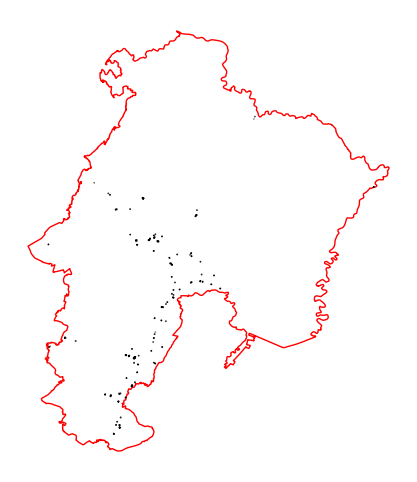

Waktu eksekusi: 0.7765002250671387 detik


In [14]:
start = time.time()
f, ax = plt.subplots(figsize=(6, 6))

# Plot boundary
demak.gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red"
)
publik_gdf.plot(
    ax=ax,
    linewidth=1,
    edgecolor="black",
    facecolor="blue"
)

ax.set_title('')
ax.set_axis_off()

plt.tight_layout
plt.savefig("demak_publik.png", bbox_inches="tight")
plt.show()
print(f"Waktu eksekusi: {time.time()-start} detik")

**Download Data Bangunan Pemerintahan**

In [15]:
class Gov:
    """
    Kelas untuk merepresentasikan dan membersihkan data bangunan pemerintahan dari OSM.
    """

    def __init__(self,
                 region_geom: Union[Polygon, gpd.GeoSeries]
                 ) -> None:
        """
        Inisialisasi objek Gov dengan data dari OSM.

        Parameters
        ----------
        region_geom : shapely.geometry.Polygon atau geopandas.GeoSeries
            Geometri wilayah yang akan diambil data bangunan pemerintahannya.
        """
        self._download_gov_data(region_geom)
        self.raw_numbers = len(self.gdf_raw)
        self.gdf_cleaned = self._clean_raw_data()
        self.cleaned_numbers = len(self.gdf_cleaned)

    def _download_gov_data(self,
                           region_geom: Union[Polygon, gpd.GeoSeries]
                           ) -> None:
        """
        Mengunduh data bangunan pemerintahan dari OSM berdasarkan geometri wilayah.

        Parameters
        ----------
        region_geom : shapely.geometry.Polygon atau geopandas.GeoSeries
            Geometri wilayah untuk batasan download data.

        Raises
        ------
        ValueError
            Jika wilayah tidak memiliki data bangunan pemerintahan di OSM.
        """
        tags = {
            "amenity": "embassy",
            "office": "government"
        }

        # Mengunduh data dari OSM
        self.gdf_raw = ox.features.features_from_polygon(region_geom, tags)

        # Hanya mengambil fitur dengan geometri Polygon atau MultiPolygon
        self.gdf_poly = (
            self.gdf_raw[self.gdf_raw.geom_type
                         .isin(["Polygon", "MultiPolygon"])]
            .copy()
            .reset_index(drop=False)
        )

        # Memeriksa apakah ada kolom amenity atau office
        if set(["amenity", "office"]).isdisjoint(set(self.gdf_poly.columns)):
            raise ValueError("Daerah tidak mempunyai data bangunan pemerintahan di OSM.")

        # Memilih kolom yang relevan
        self.gdf_poly = self.gdf_poly[["id", "geometry"]]


    def _clean_raw_data(self) -> gpd.GeoDataFrame:
        """
        Membersihkan dan menstandarisasi data bangunan pemerintahan.

        Returns
        -------
        geopandas.GeoDataFrame
            Data bangunan pemerintahan yang sudah dibersihkan dengan kolom
            object_type yang seragam (semua bertipe 'government').
        """
        # Bekerja pada copy agar tidak mengubah data mentah
        cleaned = self.gdf_poly.copy()

        cleaned = _remove_containing_polys(cleaned)

        # Menambahkan kolom object_type dengan nilai seragam
        cleaned["object_type"] = "government"

        # Memilih kolom yang relevan
        cleaned = cleaned[["id", "object_type", "geometry"]]

        return cleaned

In [16]:
start = time.time()
pemerintahan = Gov(demak.geom)
print(f"Banyaknya data sebelum dibersihkan: {pemerintahan.raw_numbers}")
print(f"Banyaknya data setelah dibersihkan: {pemerintahan.cleaned_numbers}")
pemerintahan_gdf = pemerintahan.gdf_cleaned
print(f"Waktu eksekusi: {time.time()-start} detik")
pemerintahan_gdf.head(5)

Banyaknya data sebelum dibersihkan: 225
Banyaknya data setelah dibersihkan: 9
Waktu eksekusi: 3.2112464904785156 detik


,id,object_type,geometry
0,307386968,government,"POLYGON ((110.58247 -6.8802, 110.58273 -6.8803..."
1,309666243,government,"POLYGON ((110.63782 -6.89286, 110.63809 -6.892..."
2,530736086,government,"POLYGON ((110.50351 -7.02295, 110.50353 -7.022..."
3,655859539,government,"POLYGON ((110.51217 -7.02674, 110.51214 -7.026..."
4,1262206580,government,"POLYGON ((110.53337 -6.8622, 110.5334 -6.86214..."


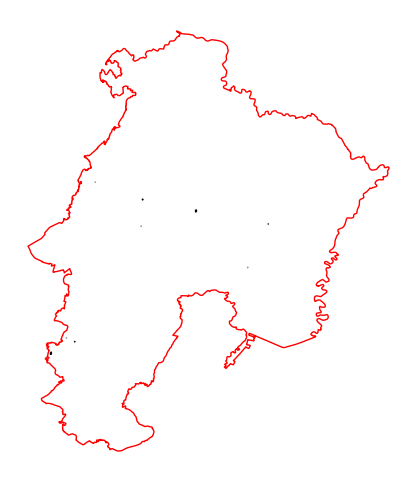

Waktu eksekusi: 0.7971398830413818 detik


In [17]:
start = time.time()
f, ax = plt.subplots(figsize=(6, 6))

# Plot boundary
demak.gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red"
)

pemerintahan_gdf.plot(
    ax=ax,
    linewidth=1,
    edgecolor="black",
    facecolor="blue"
)

ax.set_title('')
ax.set_axis_off()

plt.tight_layout
plt.savefig("demak_pemerintahan.png", bbox_inches="tight")
plt.show()
print(f"Waktu eksekusi: {time.time()-start} detik")

# Menggabungkan Data

In [18]:
eksposur = pd.concat([infrastruktur_gdf,
           publik_gdf,
           pemerintahan_gdf]).reset_index(drop = True)
eksposur

,id,object_type,geometry
0,1297006145,secondary,"LINESTRING (110.54739 -7.13399, 110.54779 -7.1..."
1,926648676,residential,"LINESTRING (110.5513 -7.12903, 110.55136 -7.12..."
2,962553588,residential,"LINESTRING (110.55303 -7.12839, 110.55317 -7.1..."
3,926669083,residential,"LINESTRING (110.55167 -7.12827, 110.55193 -7.1..."
4,962472991,residential,"LINESTRING (110.55191 -7.12768, 110.55203 -7.1..."
...,...,...,...
22202,1262206580,government,"POLYGON ((110.53337 -6.8622, 110.5334 -6.86214..."
22203,1282951900,government,"POLYGON ((110.58124 -6.90773, 110.5813 -6.9077..."
22204,1301574053,government,"POLYGON ((110.71338 -6.90534, 110.71347 -6.905..."
22205,1319043725,government,"POLYGON ((110.69194 -6.95019, 110.69189 -6.950..."


#**Vulnerability Curve**

In [19]:
vulnerability_path = "https://zenodo.org/records/10203846/files/Table_D2_Multi-Hazard_Fragility_and_Vulnerability_Curves_V1.0.0.xlsx?download=1"
vul_df = pd.read_excel(vulnerability_path,sheet_name='F_Vuln_Depth')

In [20]:
# Mendefinisikan tipe infrastruktur yang akan dianalisis
types = ["trunk", "primary", "motorway",
         "secondary", "tertiary", "residential",
         "school", "health", "government"]

# Kurva kerusakan untuk setiap tipe infrastruktur
# Format: F{unique_id} mengacu pada ID kurva di vul_df
curves = ["F7.5", "F7.5", "F7.5",
          "F7.7", "F7.7", "F7.9",
          "F21.4", "F21.4", "F21.7"]

# Memetakan tipe infrastruktur ke ID kurva yang sesuai
selected_curves = dict(zip(types, curves))

# Memilih data kurva kerusakan dari vulnerability dataframe.
damage_curves = vul_df[['ID number'] + list(selected_curves.values())]

# Mengambil baris dengan kedalaman 4-125 (rentang yang relevan)
damage_curves = damage_curves.iloc[4:125, :]

# Mengatur kolom ID number sebagai index (depth)
damage_curves.set_index('ID number', inplace=True)
damage_curves.index = damage_curves.index.rename('Depth')

# Mengkonversi tipe data ke float32 untuk efisiensi memori
damage_curves = damage_curves.astype(np.float32)

# Mengganti nama kolom dengan tipe infrastruktur yang lebih mudah dibaca
damage_curves.columns = types

# Mengisi nilai kosong dengan metode forward fill
damage_curves = damage_curves.ffill()

damage_curves.head(5)

,trunk,primary,motorway,secondary,tertiary,residential,school,health,government
Depth,,,,,,,,,
0,0.000,0.000,0.000,0.0000,0.0000,0.000,0.000000,0.000000,0.000
0.05,0.002,0.002,0.002,0.0015,0.0015,0.012,0.037679,0.037679,0.005
0.1,0.004,0.004,0.004,0.0030,0.0030,0.024,0.075358,0.075358,0.010
0.15,0.006,0.006,0.006,0.0045,0.0045,0.036,0.113037,0.113037,0.015
0.2,0.008,0.008,0.008,0.0060,0.0060,0.048,0.150716,0.150716,0.020


#**Maximum Damage**

In [21]:
maxdam = [4.5,4.5,4.5,        # Jalan: trunk, primary, motorway
           0.18,0.18,0.12,    # Jalan: secondary, tertiary, residential
           2.5,2.5,0.5]       # Bangunan: school, health, government

# Memetakan tipe infrastruktur ke nilai maksimum kerusakan
maxdam_dict = dict(zip(types, maxdam))

# Konversi ke DataFrame dengan format yang lebih rapi
maxdam = pd.DataFrame.from_dict(maxdam_dict, orient='index').reset_index()

# Memberi nama kolom yang deskriptif
maxdam.columns = ['object_type', 'damage']

#**Penghitungan Kerugian Akibat Banjir**

In [22]:
def _create_grid(bbox: shapely.Geometry, height: float) -> np.ndarray:
    """
    Membuat grid vektor reguler di atas bounding box.

    Parameters
    ----------
    bbox : shapely.Geometry
        Bounding box yang akan ditutupi oleh grid.
    height : float
        Tinggi sel grid (diasumsikan sel berbentuk persegi).

    Returns
    -------
    np.ndarray
        Array dari polygon Shapely yang membentuk grid.
    """
    # Mengambil batas bounding box (xmin, ymin, xmax, ymax)
    total_bounds = shapely.total_bounds(bbox)
    xmin, ymin = total_bounds[0], total_bounds[1]
    xmax, ymax = total_bounds[2], total_bounds[3]

    # Menghitung jumlah baris dan kolom yang diperlukan
    rows = int(np.ceil((ymax - ymin) / height))
    cols = int(np.ceil((xmax - xmin) / height))

    # Menentukan titik sudut awal
    x_left_origin = xmin
    x_right_origin = xmin + height
    y_top_origin = ymax
    y_bottom_origin = ymax - height

    # Membuat grid secara iteratif
    res_geoms = []
    for countcols in range(cols):
        y_top = y_top_origin
        y_bottom = y_bottom_origin
        for countrows in range(rows):
            res_geoms.append(
                (
                    (
                        (x_left_origin, y_top),
                        (x_right_origin, y_top),
                        (x_right_origin, y_bottom),
                        (x_left_origin, y_bottom),
                    )
                )
            )
            y_top = y_top - height
            y_bottom = y_bottom - height
        x_left_origin = x_left_origin + height
        x_right_origin = x_right_origin + height

    # Mengembalikan grid sebagai polygon shapely
    return shapely.polygons(res_geoms)


def _remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Menggabungkan coverage dan values.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame dengan kemungkinan entri index yang duplikat.

    Returns
    -------
    pandas.DataFrame
        DataFrame yang sudah dibersihkan dari duplikasi.
    """
    no_duplicates = []

    for row in df.groupby(level=0):
        if len(row[1]) == 1:
            # Menyimpan data tunggal apa adanya
            no_duplicates.append(
                [
                    row[0],
                    row[1]["coverage"].values[0],
                    row[1]["values"].values[0],
                ]
            )
        elif len(row[1]) > 1:
            # Menggabungkan coverage dari semua duplikat
            import itertools
            cov_all = list(itertools.chain.from_iterable(row[1]["coverage"].values))

            # Menggabungkan values dari semua duplikat
            val_all = list(itertools.chain.from_iterable(row[1]["values"].values))

            # Menyimpan hasil penggabungan
            no_duplicates.append([row[0], cov_all, val_all])

    # Membuat DataFrame baru tanpa duplikat
    df_no_duplicates = pd.DataFrame(
        no_duplicates, columns=["index", "coverage", "values"]
    ).set_index("index")

    return df_no_duplicates

def _get_damage_per_object(asset: pd.Series,
                           curves: pd.DataFrame,
                           cell_area_m2: float
                           ) -> float:
    """
    Menghitung kerusakan untuk satu aset menggunakan interpolasi kerentanan.

    Parameters
    ----------
    asset : pandas.Series
        Satu fitur aset dengan atribut geometry, values, object_type,
        coverage, dan maximum_damage.
    curves : pandas.DataFrame
        Dataframe kurva kerentanan dengan index kedalaman dan kolom tipe objek.
    cell_area_m2 : float
        Luas sel grid dalam meter persegi.

    Returns
    -------
    float
        Estimasi nilai kerusakan untuk aset tersebut.

    Raises
    ------
    ValueError
        Jika tipe geometri tidak didukung (harus Polygon, MultiPolygon,
        LineString, atau MultiLineString) atau tipe objek tidak ditemukan
        di kurva.
    """
    # Menghitung coverage berdasarkan tipe geometri
    if asset.geometry.geom_type in ("Polygon", "MultiPolygon"):
        coverage = np.array(asset["coverage"]) * cell_area_m2
    elif asset.geometry.geom_type in ("LineString", "MultiLineString"):
        coverage = asset["coverage"]
    else:
        raise ValueError(f"Tipe geometri {asset.geometry.geom_type} tidak didukung")

    # Menghitung kerusakan: interpolasi nilai hazard * coverage * maximum_damage
    damage_interpolated = np.interp(asset["values"],
                    curves.index,
                    curves[asset["object_type"]].values)
    object_loss = np.sum(damage_interpolated* coverage) * asset["maximum_damage"]

    return object_loss

class Loss:
    """
    Kelas untuk menghitung kerugian (loss) berdasarkan hazard, eksposur, dan kurva kerusakan.

    Attributes
    ----------
    hazard_raw : xr.DataArray
        Data hazard mentah (belum diproyeksikan).
    eksposur_raw : geopandas.GeoDataFrame
        Data eksposur mentah (belum diproyeksikan).
    damage_curves : pandas.DataFrame
        Kurva kerusakan untuk setiap tipe objek.
    maxdam : pandas.DataFrame
        Dataframe dengan kolom object_type dan damage (nilai maksimum kerusakan).
    hazard : xr.DataArray
        Data hazard yang sudah diproyeksikan ke EPSG:3857.
    eksposur : geopandas.GeoDataFrame
        Data eksposur yang sudah diproses dengan kolom loss.
    total_loss : float
        Total estimasi kerugian dari semua aset.
    """

    def __init__(self,
                 hazard: xr.DataArray,
                 eksposur: gpd.GeoDataFrame,
                 damage_curves: pd.DataFrame,
                 maxdam: pd.DataFrame
                 ) -> None:
        """
        Inisialisasi objek Loss dengan data hazard, eksposur, dan kurva kerusakan.

        Parameters
        ----------
        hazard : xr.DataArray
            Data hazard (banjir, gempa, dll) dalam format xarray.
        eksposur : geopandas.GeoDataFrame
            Data eksposur aset dengan geometri dan atribut object_type.
        damage_curves : pandas.DataFrame
            Kurva kerusakan untuk setiap tipe objek.
        maxdam : pandas.DataFrame
            Dataframe dengan kolom object_type dan damage (nilai maksimum kerusakan).
        """
        self.hazard_raw = hazard
        self.eksposur_raw = eksposur
        self.damage_curves = damage_curves
        self.maxdam = maxdam

    def calculate(self) -> gpd.GeoDataFrame:
        """
        Menghitung kerugian untuk setiap aset berdasarkan overlay hazard dan eksposur.

        Returns
        -------
        geopandas.GeoDataFrame
            Dataframe eksposur dengan kolom tambahan:
            - coverage: persentase tutupan grid pada aset
            - values: nilai hazard pada aset
            - maximum_damage: nilai maksimum kerusakan
            - loss: estimasi kerugian
        """
        # Proyeksi ulang ke EPSG:3857 untuk konsistensi
        hazard = self.hazard_raw.rio.reproject("EPSG:3857")
        eksposur = self.eksposur_raw.to_crs(epsg=3857)

        # Ukuran sel grid dalam meter
        grid_cell_size = 50000  # 50km x 50km

        # Membuat grid berdasarkan batas hazard
        hazard_bound = hazard.rio.bounds()
        bbox = shapely.box(
            hazard_bound[0],
            hazard_bound[1],
            hazard_bound[2],
            hazard_bound[3],
        )
        grid = _create_grid(bbox, grid_cell_size)

        # Mengambil semua batas grid
        all_bounds = gpd.GeoDataFrame(grid, columns=["geometry"]).bounds

        collect_overlay = []

        # Looping untuk setiap grid cell
        for bounds in tqdm(
            all_bounds.itertuples(),
            total=len(all_bounds),
            desc="Overlay raster dengan vector"
        ):
            try:
                # Memotong hazard berdasarkan batas grid
                subset_hazard = hazard.rio.clip_box(
                    minx=bounds.minx,
                    miny=bounds.miny,
                    maxx=bounds.maxx,
                    maxy=bounds.maxy,
                )

                # Membuat bounding box untuk spatial index
                sub_bbox = shapely.box(
                    bounds.minx, bounds.miny, bounds.maxx, bounds.maxy
                )

                # Mencari aset-aset yang beririsan dengan grid
                candidate_idx = eksposur.sindex.query(
                    sub_bbox, predicate="intersects"
                )
                subset_eksposur = eksposur.iloc[candidate_idx]

                # Ekstraksi nilai hazard dan coverage
                values_and_coverage_per_object = exact_extract(
                    subset_hazard,
                    subset_eksposur[["geometry"]],
                    ["coverage", "values"],
                    include_geom=False,
                    output="pandas",
                    strategy="raster-sequential"
                )

                # Menghubungkan hasil dengan fitur asli
                values_and_coverage_per_object.index = subset_eksposur.index
                collect_overlay.append(values_and_coverage_per_object)

            except Exception as e:
                print(f"Terjadi error pada grid {bounds.Index}: {e}")

        # Menggabungkan semua hasil overlay
        df = pd.concat(collect_overlay).sort_index()

        # Menghapus duplikat (aset yang terkena multiple grid cells)
        df_no_duplicates = _remove_duplicates(df)

        # Menambahkan coverage dan values ke eksposur
        eksposur.loc[df_no_duplicates.index, "coverage"] = df_no_duplicates["coverage"]
        eksposur.loc[df_no_duplicates.index, "values"] = df_no_duplicates["values"]

        # Menghitung luas pixel dalam meter persegi
        cell_area_m2 = abs(
            (hazard.x[1].values - hazard.x[0].values)
            * (hazard.y[0].values - hazard.y[1].values)
        )

        # Menggabungkan dengan nilai maksimum kerusakan (maxdam)
        eksposur = (
            eksposur.merge(self.maxdam, on='object_type', how='left')
            .rename(columns={'damage': 'maximum_damage'})
        )

        # Menghitung kerugian per aset dengan progress bar
        tqdm.pandas(desc="Menghitung kerusakan per aset")
        eksposur["loss"] = eksposur.progress_apply(
            lambda _object: _get_damage_per_object(
                _object, self.damage_curves, cell_area_m2
            ),
            axis=1,
        )

        return eksposur

In [23]:
loss_rp100 = Loss(hazard_rp100_clipped,
         eksposur,
         damage_curves,
         maxdam)
eksposur_calculated = loss_rp100.calculate()
total_loss = sum(eksposur_calculated.loss)
print(f"\n\nTotal kerugian yang diakibatkan kejadian banjir 100 tahunan adalah \
\n {np.round(total_loss,2)} juta atau {np.round(total_loss/1000,2)} miliar")

Menghitung kerusakan per aset: 100%|██████████| 22207/22207 [00:01<00:00, 12328.77it/s]



Total kerugian yang diakibatkan kejadian banjir 100 tahunan adalah 
 259121.32 juta atau 259.12 miliar


In [24]:
eks = eksposur_calculated.copy()
# Hitung damage per kategori
damage_per_type = eks.groupby("object_type")["loss"].sum()
damage_per_type

,loss
object_type,
government,144.825057
health,1503.713559
motorway,13786.921726
primary,4230.696247
residential,19769.821377
school,203411.764830
secondary,640.785588
tertiary,1697.567465
trunk,13935.222304


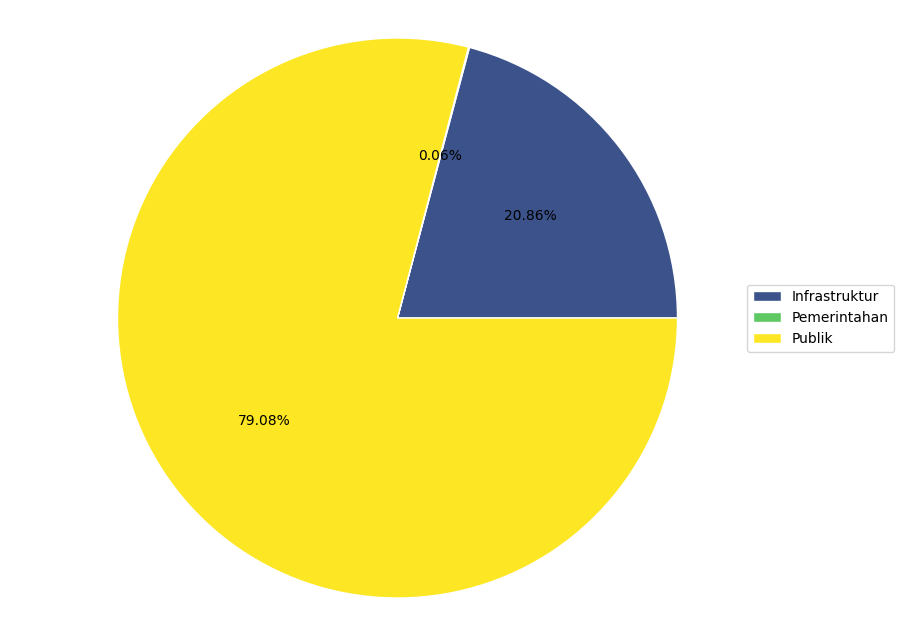

In [25]:
eks = eksposur_calculated.copy()

# Mapping kategori
kategori = {
    "trunk": "infrastruktur", "motorway": "infrastruktur",
    "primary": "infrastruktur", "secondary": "infrastruktur",
    "tertiary": "infrastruktur", "residential": "infrastruktur",
    "health": "publik", "school": "publik",
    "government": "pemerintahan"
}

eks["object_type"] = eks["object_type"].replace(kategori)

# Hitung damage per kategori
damage_per_type = eks.groupby("object_type")["loss"].sum()

# Plot
colors = ['#3b528b', '#5ec962', '#fde725']
labels = [x.capitalize() for x in damage_per_type.index]

plt.figure(figsize=(10, 8))
plt.pie(damage_per_type.values,
        autopct='%1.2f%%',
        colors=colors,
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
plt.axis('equal')
plt.legend(labels, loc='right', bbox_to_anchor=(1.15, 0.5))
plt.savefig("visualisasi per tipe_rp100.png")

plt.show()

#**Penggunaan Package DamageScanner untuk Menghitung Kerugian Banjir**

In [26]:
# Proyeksi ulang hazard dan eksposur ke EPSG:3857 (Web Mercator)
hazard_proj = hazard_rp100_clipped.rio.reproject("EPSG:3857")
eksposur_proj = eksposur.to_crs(epsg=3857)

# Inisialisasi objek DamageScanner
loss_rp100_ds = DamageScanner(
    hazard_proj,
    eksposur_proj,
    damage_curves,
    maxdam
)

# Eksekusi perhitungan
eksposur_calculated_ds = loss_rp100_ds.calculate()

# Hitung total kerugian (asumsi kolom 'damage' dalam satuan juta)
total_loss_ds = sum(eksposur_calculated_ds["damage"])

# Tampilkan hasil
print(f"\n\nTotal kerugian yang diakibatkan kejadian banjir 100 tahunan adalah")
print(f"{np.round(total_loss_ds, 2)} juta atau {np.round(total_loss_ds / 1000, 2)} miliar")

Calculating damage: 100%|██████████| 22207/22207 [00:01<00:00, 15899.32it/s]



Total kerugian yang diakibatkan kejadian banjir 100 tahunan adalah
259121.32 juta atau 259.12 miliar
